In [15]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: C:\Users\Lenovo


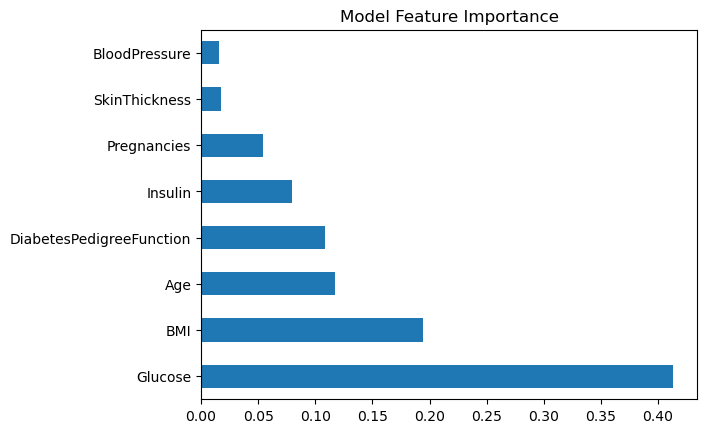

Extreme Case Probability: 94.10%


In [16]:
# Run this cell in your notebook to see what the model is actually looking at
import matplotlib.pyplot as plt

feature_imp = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
feature_imp.plot(kind='barh', title="Model Feature Importance")
plt.show()

# Now, test the model with an ABSOLUTE EXTREME case
extreme_test = pd.DataFrame([{
    'Pregnancies': 10, 'Glucose': 250, 'BloodPressure': 190, 
    'SkinThickness': 50, 'Insulin': 800, 'BMI': 60.0, 
    'DiabetesPedigreeFunction': 2.5, 'Age': 80
}])[features]
extreme_test['DiabetesPedigreeFunction'] = np.log1p(extreme_test['DiabetesPedigreeFunction'])
extreme_scaled = scaler.transform(extreme_test)

print(f"Extreme Case Probability: {best_model.predict_proba(extreme_scaled)[0][1]:.2%}")

In [17]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# 1. Load and perform strict cleaning
df = pd.read_csv(r"C:\Users\Lenovo\AI_ML\diabetes.csv")
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df = df.dropna() # DROPPING is safer than filling medians to avoid bias

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 2. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train
model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train_scaled, y_train)

# 4. Export with unique v3 names
joblib.dump(model, 'diab_model_v3.pkl')
joblib.dump(scaler, 'diab_scaler_v3.pkl')
joblib.dump(X.columns.tolist(), 'diab_features_v3.pkl')

print("Model V3 exported. Features:", X.columns.tolist())

Model V3 exported. Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
